# 04 — Draft Efficiency: The Draft Steal Score
**Finding Hidden Gems: 25 Years of WNBA Draft Value and Player Success**

For every player:

```
Draft Steal Score  =  Career Value  -  Expected Value of Draft Slot
```

Where *Expected Value of Draft Slot* is the LOWESS-smoothed curve built in Notebook 03
(`data/draft_pick_value.csv`), and *Career Value* is career win shares, zero-filled for
players who never played — consistent with how the expected-value curve itself was built.

A positive score means a player outproduced what their draft slot predicted (a **steal**);
a negative score means they underproduced (a **bust**, in the relative sense — even a very
good player picked #1 can post a mildly negative score if they underperform the very high
bar of the #1 pick).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

COLOR_MAIN = '#E56020'
COLOR_ALT  = '#1B3A5C'
COLOR_GREY = '#9AA5B1'
COLOR_BUST = '#B23A48'

df = pd.read_csv('../data/wnba_draft_clean.csv')
pick_value = pd.read_csv('../data/draft_pick_value.csv')

df['win_shares_ev'] = df['win_shares'].fillna(0)
df = df.merge(pick_value[['overall_pick', 'expected_win_shares']], on='overall_pick', how='left')
df['steal_score'] = df['win_shares_ev'] - df['expected_win_shares']
df[['player','year','overall_pick','win_shares_ev','expected_win_shares','steal_score']].head()


,player,year,overall_pick,win_shares_ev,expected_win_shares,steal_score
0,Tina Thompson,1997,1,60.7,22.216628,38.483372
1,Pamela McGee,1997,2,2.0,19.831651,-17.831651
2,Jamila Wideman,1997,3,-1.3,17.451664,-18.751664
3,Eva Nemcova,1997,4,10.4,15.076988,-4.676988
4,Tammi Reiss,1997,5,-0.1,12.701385,-12.801385


## Important caveat: career-length truncation

Career win shares accumulate over a player's whole career. A 1997 draftee has had up to
19 seasons to accumulate value; a 2022 draftee has had exactly **1**. Left unhandled, every
"biggest bust" leaderboard would just be a list of recent draft classes that haven't had
time to develop — not a real signal about the pick.


In [2]:
avg_years_by_class = df.groupby('year')['years_played'].mean()
max_years_by_class = df.groupby('year')['years_played'].max()
print("Average / max seasons played, by draft class (last 10 years shown):")
print(pd.DataFrame({'avg_years_played': avg_years_by_class, 'max_years_played': max_years_by_class}).tail(10).round(2))


Average / max seasons played, by draft class (last 10 years shown):
      avg_years_played  max_years_played
year                                    
2013              3.19                 9
2014              3.72                 9
2015              2.83                 8
2016              2.50                 7
2017              2.17                 6
2018              2.19                 5
2019              2.22                 4
2020              1.56                 3
2021              0.89                 2
2022              0.61                 1


In [3]:
# Classes from 2021-2022 have had at most 2 seasons to accumulate value - not enough
# to fairly judge against a career-value baseline. We flag and exclude them from the
# headline steal/bust leaderboards below (they remain in the full saved table).
df['too_early_to_judge'] = df['year'] >= 2021
print(f"Flagged as too early to judge: {df['too_early_to_judge'].sum()} picks (2021-2022 classes)")

judgeable = df[~df['too_early_to_judge']].copy()


Flagged as too early to judge: 72 picks (2021-2022 classes)


## Biggest steals ever

In [4]:
biggest_steals = judgeable.nlargest(15, 'steal_score')[
    ['player','year','overall_pick','round','college_display','win_shares_ev','expected_win_shares','steal_score']
]
biggest_steals.round(2)


,player,year,overall_pick,round,college_display,win_shares_ev,expected_win_shares,steal_score
188,Tamika Catchings,2001,3,1,Tennessee,93.7,17.45,76.25
103,Taj McWilliams-Franklin,1999,32,3,St. Edward's,53.9,0.05,53.85
515,Sylvia Fowles,2008,2,1,LSU,73.5,19.83,53.67
186,Lauren Jackson,2001,1,1,NaN,73.0,22.22,50.78
356,Diana Taurasi,2004,1,1,UConn,71.2,22.22,48.98
196,Penny Taylor,2001,11,1,NaN,49.0,1.84,47.16
195,Katie Douglas,2001,10,1,Purdue,48.9,2.88,46.02
365,Rebekkah Brunson,2004,10,1,Georgetown,48.6,2.88,45.72
359,Lindsay Whalen,2004,4,1,Minnesota,59.8,15.08,44.72
514,Candace Parker,2008,1,1,Tennessee,62.2,22.22,39.98


## Biggest busts ever

(Most negative steal score — includes very high picks who didn't meet a high bar, and low picks who added negative value.)

In [5]:
biggest_busts = judgeable.nsmallest(15, 'steal_score')[
    ['player','year','overall_pick','round','college_display','win_shares_ev','expected_win_shares','steal_score']
]
biggest_busts.round(2)


,player,year,overall_pick,round,college_display,win_shares_ev,expected_win_shares,steal_score
123,Tausha Mills,2000,2,1,Alabama,0.4,19.83,-19.43
315,Chantelle Anderson,2003,2,1,Vanderbilt,0.8,19.83,-19.03
921,AD Durr,2019,2,1,Louisville,0.9,19.83,-18.93
2,Jamila Wideman,1997,3,1,Stanford,-1.3,17.45,-18.75
124,Edwina Brown,2000,3,1,Texas,-0.5,17.45,-17.95
1,Pamela McGee,1997,2,1,USC,2.0,19.83,-17.83
850,Evelyn Akhator,2017,3,1,Kentucky,-0.2,17.45,-17.65
849,Alaina Coates,2017,2,1,South Carolina,2.3,19.83,-17.53
957,Satou Sabally,2020,2,1,Oregon,2.4,19.83,-17.43
778,Kaleena Mosqueda-Lewis,2015,3,1,UConn,0.4,17.45,-17.05


## Most valuable second-round-and-later picks

The steals leaderboard above is dominated by lottery picks simply because they carry the
highest expected value to beat *in absolute terms* — a small overperformance in raw win
shares can't compete with a real Round 1 breakout. Restricting to Round 2+ isolates the
"how should a GM draft *outside* the top of the board" question directly.


In [6]:
late_steals = judgeable[judgeable['round'] >= 2].nlargest(15, 'steal_score')[
    ['player','year','overall_pick','round','college_display','win_shares_ev','expected_win_shares','steal_score']
]
late_steals.round(2)


,player,year,overall_pick,round,college_display,win_shares_ev,expected_win_shares,steal_score
103,Taj McWilliams-Franklin,1999,32,3,St. Edward's,53.9,0.05,53.85
203,Tammy Sutton-Brown,2001,18,2,Rutgers,32.9,0.12,32.78
722,Emma Meesseman,2013,19,2,NaN,29.2,0.11,29.09
390,Jia Perkins,2004,35,3,Texas Tech,28.3,0.03,28.27
681,Tiffany Hayes,2012,14,2,UConn,28.4,0.42,27.98
43,Tangela Smith,1998,12,2,Iowa,27.8,1.14,26.66
13,Tamecka Dixon,1997,14,2,Kansas,22.5,0.42,22.08
491,Camille Little,2007,17,2,UNC,21.7,0.16,21.54
538,Leilani Mitchell,2008,25,2,Utah,21.0,0.05,20.95
612,Alysha Clark,2010,17,2,Middle Tennessee,20.6,0.16,20.44


## Most overperforming and underperforming players, as a rate

Steal score is a *career total* — it rewards longevity as much as quality. As a complement, here's steal score **per season played**, restricted to players with at least 3 seasons (enough of a track record for a rate stat to mean something).

In [7]:
rate_pool = judgeable[(judgeable['years_played'] >= 3)].copy()
rate_pool['steal_score_per_season'] = rate_pool['steal_score'] / rate_pool['years_played']

print("Most overperforming per season:")
display_cols = ['player','year','overall_pick','years_played','steal_score','steal_score_per_season']
print(rate_pool.nlargest(10, 'steal_score_per_season')[display_cols].round(2).to_string(index=False))
print()
print("Most underperforming per season:")
print(rate_pool.nsmallest(10, 'steal_score_per_season')[display_cols].round(2).to_string(index=False))


Most overperforming per season:
                 player  year  overall_pick  years_played  steal_score  steal_score_per_season
       Tamika Catchings  2001             3            15        76.25                    5.08
         Lauren Jackson  2001             1            12        50.78                    4.23
             Maya Moore  2011             1             8        31.28                    3.91
Taj McWilliams-Franklin  1999            32            14        53.85                    3.85
         Emma Meesseman  2013            19             8        29.09                    3.64
           Penny Taylor  2001            11            13        47.16                    3.63
       Yolanda Griffith  1999             2            11        39.57                    3.60
          Sylvia Fowles  2008             2            15        53.67                    3.58
          Jonquel Jones  2016             6             6        21.00                    3.50
          Katie Do

## Steal score distribution

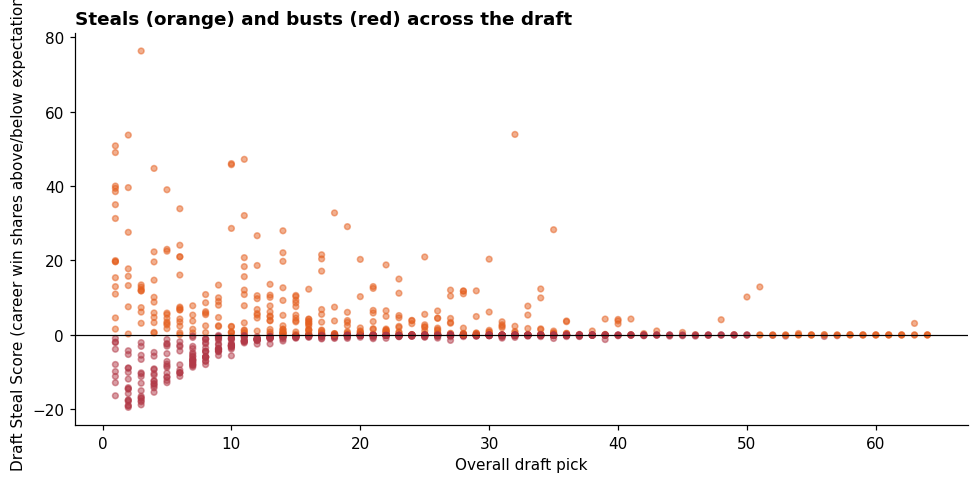

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = np.where(judgeable['steal_score'] >= 0, COLOR_MAIN, COLOR_BUST)
ax.scatter(judgeable['overall_pick'], judgeable['steal_score'], s=14, alpha=0.5, c=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Overall draft pick')
ax.set_ylabel('Draft Steal Score (career win shares above/below expectation)')
ax.set_title('Steals (orange) and busts (red) across the draft', loc='left', fontweight='bold')
plt.tight_layout()
plt.savefig('../dashboard/chart_steal_score_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


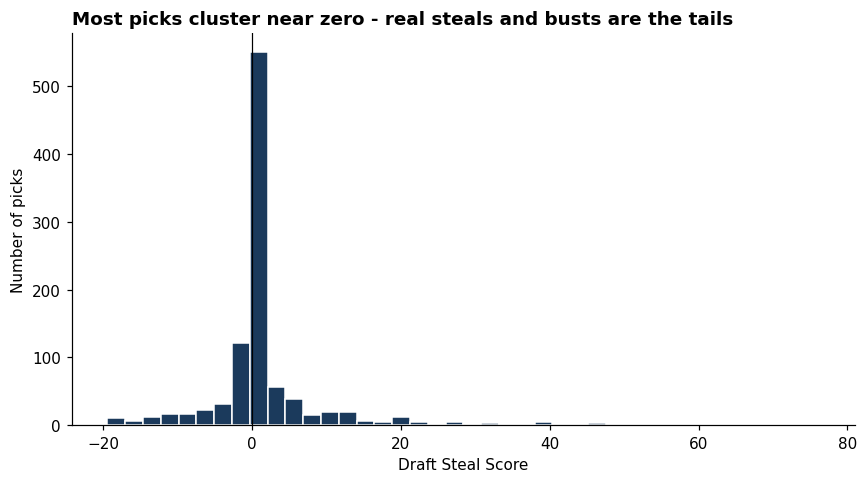

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(judgeable['steal_score'], bins=40, color=COLOR_ALT, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Draft Steal Score')
ax.set_ylabel('Number of picks')
ax.set_title('Most picks cluster near zero - real steals and busts are the tails', loc='left', fontweight='bold')
plt.tight_layout()
plt.savefig('../dashboard/chart_steal_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## Save steal scores

Full table (including the 2021-2022 "too early to judge" rows, clearly flagged) for reuse in Phase 5 (team drafting ability) and Phase 7 (hidden gem finder).

In [10]:
out_cols = ['overall_pick','year','round','team','franchise','player','college_display',
            'is_international','years_played','win_shares_ev','expected_win_shares',
            'steal_score','too_early_to_judge']
steal_table = df[out_cols].copy()
steal_table.to_csv('../data/draft_steal_scores.csv', index=False)
print(f"Saved data/draft_steal_scores.csv - {len(steal_table)} rows")
steal_table.head()


Saved data/draft_steal_scores.csv - 1064 rows


,overall_pick,year,round,team,franchise,player,college_display,is_international,years_played,win_shares_ev,expected_win_shares,steal_score,too_early_to_judge
0,1,1997,1,Houston Comets,Houston Comets,Tina Thompson,USC,False,17,60.7,22.216628,38.483372,False
1,2,1997,1,Sacramento Monarchs,Sacramento Monarchs,Pamela McGee,USC,False,2,2.0,19.831651,-17.831651,False
2,3,1997,1,Los Angeles Sparks,Los Angeles Sparks,Jamila Wideman,Stanford,False,4,-1.3,17.451664,-18.751664,False
3,4,1997,1,Cleveland Rockers,Cleveland Rockers,Eva Nemcova,NaN,True,5,10.4,15.076988,-4.676988,False
4,5,1997,1,Utah Starzz,Las Vegas Aces,Tammi Reiss,Virginia,False,2,-0.1,12.701385,-12.801385,False
